### Calibrating our Call price
Key Source: Derivative Analytics with Python by Yves Hilpisch: Chapter 8. We calibrate our call option price models.



In [2]:
import numpy as np
import scipy.optimize as opt
from pricing.OptionsPrice import FourierPricing, F_call_price_Lewis, char_Jump
from data.data_extraction import option_prices
import matplotlib.pyplot as plt

In [3]:
#Option prices extraction

selected_contracts = [7450,7475,7500,7525,7550] # Strikes

C_market = option_prices("2026-09-11","2026-09-14",selected_contracts,260914,"SPXW")

Strike: 7450 Ticker: O:SPXW260914C07450000 Close: 176.99 Volume: 18
Strike: 7475 Ticker: O:SPXW260914C07475000 Close: 156.76 Volume: 21
Strike: 7500 Ticker: O:SPXW260914C07500000 Close: 125.12 Volume: 114
Strike: 7525 Ticker: O:SPXW260914C07525000 Close: 98.8 Volume: 339
Strike: 7550 Ticker: O:SPXW260914C07550000 Close: 70.71 Volume: 965


In [4]:
r = 0.039 #Risk Free Rate: 1 month U.S. treasury yield https://www.cnbc.com/quotes/US1M
T = 1/22 # We scale the expiration according to the risk-free rate
D = 0.016 # According to: https://www.multpl.com/s-p-500-dividend-yield
S0 = 7611.44 # Opening of monday 14.09.2026

N = len(C_market) # how many strikes we are observing
C_model = np.zeros(N) # empty array to store our model prices

def M76_error_function(p0):
    '''
    sigma: volatility
    lambd: jump intensity
    muj: mean log jump size
    delta: variability of jump size
    '''
    sigma, lambd, muj, delta = p0

    for i, K in enumerate(selected_contracts):
        C_model[i] = F_call_price_Lewis(S0,sigma,D,r,K,T,char_Jump,muj,delta,lambd)

    RMSE = np.sqrt(1 / N * np.sum((C_market - C_model)**2))

    RMSE_min = min(RMSE,100)

    return RMSE_min

p0 = opt.brute(
    M76_error_function,
    (
        (0.10, 0.51, 0.05),    # sigma
        (0.0, 0.81, 0.1),      # lambda
        (-0.10, 0.01, 0.01),   # mu_J
        (0.01, 0.11, 0.02)     # delta
    )
)
result = opt.minimize(
    M76_error_function,
    p0,
    method="Nelder-Mead",
    bounds=[
        (0.0001, 1.0),    
        (0.0, 0.8),       
        (-1.0, 0.1),      
        (0.0001, 0.121)
    ],
    options={
        "xatol": 1e-5,
        "fatol": 1e-5,
        "maxiter": 750,
        "maxfev": 1500
    }
)
opt_parameters = result.x

print("Optimal Parameters:", opt_parameters)
print("RMSE:", result.fun)



C:\Users\nikit\AppData\Local\Temp\ipykernel_27080\188423336.py:36: OptimizeWarning: Initial guess is not within the specified bounds
  result = opt.minimize(


Optimal Parameters: [ 1.03354338e-04  9.58285596e-02 -1.00000000e+00  2.86971617e-02]
RMSE: 4.819603854302213


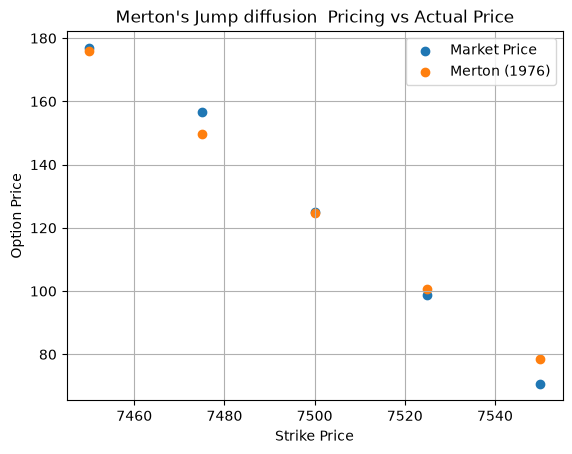

In [11]:
#We test if these parameters are valid

plt.figure()
plt.title("Merton's Jump diffusion  Pricing vs Actual Price")
plt.scatter(selected_contracts,C_market, label = "Market Price")
plt.scatter(selected_contracts,C_model, label = "Merton (1976)")
plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.legend()
plt.grid()